# MSI 5001 Introduction to AI: Concepts, Applications, and Evaluation (Capstone Project)

## Classical Machine Learning Modelling

- **Group:** 26
- **Members:** Alkaff, Dev, Kee Fong


## Overview

- Logistic Regression → PCA-50
- SVM → PCA-50
- History Gradient Boost → 1200 MFCC Features
- XGBoost → 1200 MFCC Features


## Import Statements and Setup


In [53]:
# Import Statements
# -----------------

import os
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, RobustScaler, label_binarize
from sklearn.utils import shuffle
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier, callback


In [38]:
# Global Config
# -------------

BASE_DIR = Path("D:\\MSI5001 Datasets\\Urban Sound")
RAW_TRAIN_ROOT = BASE_DIR / "raw" / "Train"
RAW_TEST_ROOT = BASE_DIR / "raw" / "Test"

MFCC_TRAIN_ROOT = BASE_DIR / "mfcc" / "Train"
MFCC_TEST_ROOT = BASE_DIR / "mfcc" / "Test"
SPECTRO_TRAIN_ROOT = BASE_DIR / "mel_spectro" / "Train"
SPECTRO_TEST_ROOT = BASE_DIR / "mel_spectro" / "Test"
WAV24_TRAIN_ROOT = BASE_DIR / "wave_24k" / "Train"
WAV24_TEST_ROOT = BASE_DIR / "wave_24k" / "Test"

MFCC_FEATS_TRAIN = BASE_DIR / "mfcc_features_train_clean.csv"    # columns: sample (file), F0..F1199, label
MFCC_FEATS_TEST = BASE_DIR / "mfcc_features_test.csv"      # columns: sample (file), F0..F1199, label
PCA50_TRAIN = BASE_DIR / "mfcc_pca50_train_clean.csv"    # columns: sample (file),label, PC1..PC50
PCA50_TEST = BASE_DIR / "mfcc_pca50_test.csv"      # columns: sample (file),label, PC1..PC50

SPLITS = ["Train", "Test"]


In [39]:
# Process Config
# --------------

RANDOM_STATE = 42  # keep consistent with training cell


In [40]:
# Helper Functions
# ----------------

def calculate_macro_metrics(y, y_hat, title):
    acc = accuracy_score(y, y_hat)
    prec = precision_score(y, y_hat, average="macro", zero_division=0)
    rec  = recall_score(y, y_hat, average="macro", zero_division=0)
    f1   = f1_score(y, y_hat, average="macro", zero_division=0)
    return [title, float(acc), float(prec), float(rec), float(f1)]


def print_macro_metrics(y, y_hat, title):
    met = calculate_macro_metrics(y_test, y_hat, title)
    print(f" === {met[0]} ===")
    print( "  Acc    | Prec   | Rec    | F1-Score")
    print(f"  {met[1]:.4f} | {met[2]:.4f} | {met[3]:.4f} | {met[4]:.4f}")


def print_classification_report(y, y_hat, title):
    print(f"\n=== Classification Report: {title} ===")
    print(classification_report(y, y_hat, digits=4, zero_division=0))


def plot_confusion_mat(y, y_hat, title, filename):
    cm = confusion_matrix(y, y_hat)

    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=[str(i) for i in range(cm.shape[1])],
        yticklabels=[str(i) for i in range(cm.shape[0])]
    )
    
    plt.title(f"Confusion Matrix — {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    
    plt.savefig(filename)
    plt.show()


In [41]:
# Class Mapping
# -------------

classes = sorted([d.name for d in MFCC_TRAIN_ROOT.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Class mapping:", class_to_idx)
print("Reverse Class mapping:", idx_to_class)


Class mapping: {'air_conditioner': 0, 'car_horn': 1, 'children_playing': 2, 'dog_bark': 3, 'drilling': 4, 'engine_idling': 5, 'gun_shot': 6, 'jackhammer': 7, 'siren': 8, 'street_music': 9}
Reverse Class mapping: {0: 'air_conditioner', 1: 'car_horn', 2: 'children_playing', 3: 'dog_bark', 4: 'drilling', 5: 'engine_idling', 6: 'gun_shot', 7: 'jackhammer', 8: 'siren', 9: 'street_music'}


## Load Dataset

- **Load** and **Shuffle** the PCA-50 CSV for Logistic Regression and SVM
- **Load** and **Shuffle** the 1200 MFCC Features CSV for Gradient Boost
- Calculate **Class Weights**


In [6]:
train_mfcc_df = pd.read_csv(MFCC_FEATS_TRAIN)  # columns: sample, F0..F1199, label
train_pca_df  = pd.read_csv(PCA50_TRAIN)       # columns: sample, label, PC1..PC50
test_mfcc_df  = pd.read_csv(MFCC_FEATS_TEST)
test_pca_df   = pd.read_csv(PCA50_TEST)

train_mfcc_df = shuffle(train_mfcc_df, random_state=RANDOM_STATE).reset_index(drop=True)
train_pca_df = shuffle(train_pca_df, random_state=RANDOM_STATE).reset_index(drop=True)

print("=== Dataset Shapes ===")
print(f"Train MFCC: {train_mfcc_df.shape}")
print(f"Test  MFCC: {test_mfcc_df.shape}")
print(f"Train PCA : {train_pca_df.shape}")
print(f"Test  PCA : {test_pca_df.shape}")


=== Dataset Shapes ===
Train MFCC: (1721, 1202)
Test  MFCC: (837, 1202)
Train PCA : (1721, 52)
Test  PCA : (837, 52)


## Logistic Regression

1. **Extract** the features (`X`) and label (`y`)
2. Use `StandardScaler()` and **fit** on Train, then **transform** both Train and Test
3. **Train** Logistic Regression on `X_train_scaled`
4. **Evaluate** by making predictions on `X_test_scaled`


In [7]:
# Extract X and y
# ---------------

X_train = train_pca_df.drop(columns=["sample", "label"])
y_train = train_pca_df["label"]

X_test = test_pca_df.drop(columns=["sample", "label"])
y_test = test_pca_df["label"]

# Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [8]:
# Calculate Class Weights
# -----------------------

classes_unique = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced",
                               classes=classes_unique,
                               y=y_train)
class_weights = dict(zip(classes_unique, weights))
print("Class weights:", class_weights)

sample_weight = np.array([class_weights[y] for y in y_train])
print("Sample weights:", sample_weight)


Class weights: {0: 0.878061224489796, 1: 2.2064102564102566, 2: 0.8825641025641026, 3: 0.8825641025641026, 4: 0.8736040609137056, 5: 0.9057894736842105, 6: 2.5686567164179106, 7: 0.7292372881355932, 8: 1.0005813953488372, 9: 0.8825641025641026}
Sample weights: [0.87360406 0.90578947 0.8825641  ... 0.87360406 1.0005814  0.72923729]


In [9]:
# Train Logistic Regression
# -------------------------

lr = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    class_weight=class_weights, # Use Class Weights here
    solver="lbfgs",
    C=1.0,
    random_state=RANDOM_STATE
)
lr.fit(X_train_scaled, y_train)


C:\Users\Alkaff\anaconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight={0: 0.878061224489796, 1: 2.2064102564102566,
                                 2: 0.8825641025641026, 3: 0.8825641025641026,
                                 4: 0.8736040609137056, 5: 0.9057894736842105,
                                 6: 2.5686567164179106, 7: 0.7292372881355932,
                                 8: 1.0005813953488372, 9: 0.8825641025641026},
                   max_iter=2000, multi_class='multinomial', random_state=42)

In [10]:
# Evaluate
# --------

y_pred_lr = lr.predict(X_test_scaled)
print_classification_report(y_test, y_pred_lr, "Logistic Regression (PCA-50)")
print_macro_metrics(y_test, y_pred_lr, "Logistic Regression (PCA-50)")



=== Classification Report: Logistic Regression (PCA-50) ===
              precision    recall  f1-score   support

           0     0.6140    0.7000    0.6542       100
           1     0.7143    0.4545    0.5556        33
           2     0.4318    0.5700    0.4914       100
           3     0.7176    0.6100    0.6595       100
           4     0.6322    0.5500    0.5882       100
           5     0.5556    0.3763    0.4487        93
           6     0.8182    0.8438    0.8308        32
           7     0.6159    0.8854    0.7265        96
           8     0.5806    0.4337    0.4966        83
           9     0.6569    0.6700    0.6634       100

    accuracy                         0.6069       837
   macro avg     0.6337    0.6094    0.6115       837
weighted avg     0.6141    0.6069    0.6013       837

 === Logistic Regression (PCA-50) ===
  Acc    | Prec   | Rec    | F1-Score
  0.6069 | 0.6337 | 0.6094 | 0.6115


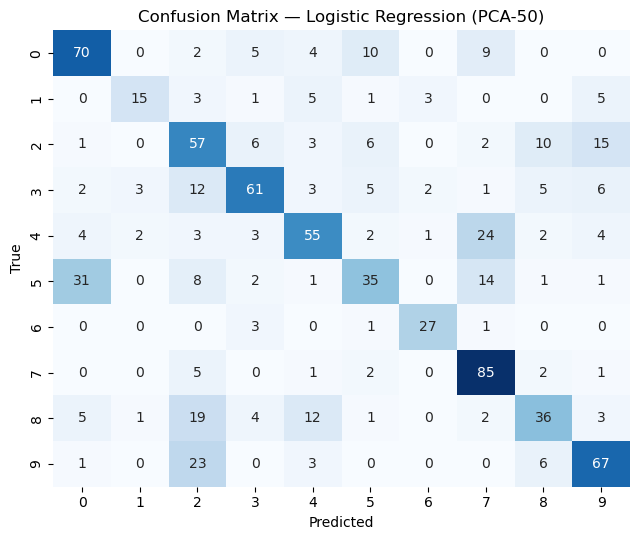

In [11]:
plot_confusion_mat(y_test, y_pred_lr, "Logistic Regression (PCA-50)", BASE_DIR / "03a_logreg_cf.png")


## SVM

1. (Already Done) **Extract** the features (`X`) and label (`y`)
2. (Already Done) Use `StandardScaler()` and **fit** on Train, then **transform** both Train and Test
3. Create **SVM Pipeline** and **Grid Search** params
4. **Execute** the Grid Search for SVM on `X_train_scaled`
5. **Evaluate** by making predictions on `X_test_scaled`


In [12]:
# Pipeline and Grid Parameters
# ----------------------------

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight=class_weights, random_state=RANDOM_STATE))
])

param_grid = {
    "svm__C":     [0.5, 1, 2, 4],
    "svm__gamma": ["scale", 1/50]  # 1/num_features as a simple fixed option
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=2
)


In [13]:
# Execute Grid Search
# -------------------

grid.fit(X_train, y_train)
print("Best SVM params:", grid.best_params_)
print("Best CV macro-F1:", f"{grid.best_score_:.4f}")

best_svm = grid.best_estimator_


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best SVM params: {'svm__C': 4, 'svm__gamma': 'scale'}
Best CV macro-F1: 0.8370


In [14]:
# Evaluate
# --------

y_pred_svm = best_svm.predict(X_test)
print_classification_report(y_test, y_pred_svm, "SVM (RBF, PCA-50)")
print_macro_metrics(y_test, y_pred_svm, "SVM (RBF, PCA-50)")



=== Classification Report: SVM (RBF, PCA-50) ===
              precision    recall  f1-score   support

           0     0.5556    0.7500    0.6383       100
           1     0.7727    0.5152    0.6182        33
           2     0.4648    0.6600    0.5455       100
           3     0.5966    0.7100    0.6484       100
           4     0.6567    0.4400    0.5269       100
           5     0.5690    0.3548    0.4371        93
           6     0.9655    0.8750    0.9180        32
           7     0.6903    0.8125    0.7464        96
           8     0.6000    0.3253    0.4219        83
           9     0.6355    0.6800    0.6570       100

    accuracy                         0.6057       837
   macro avg     0.6507    0.6123    0.6158       837
weighted avg     0.6168    0.6057    0.5958       837

 === SVM (RBF, PCA-50) ===
  Acc    | Prec   | Rec    | F1-Score
  0.6057 | 0.6507 | 0.6123 | 0.6158


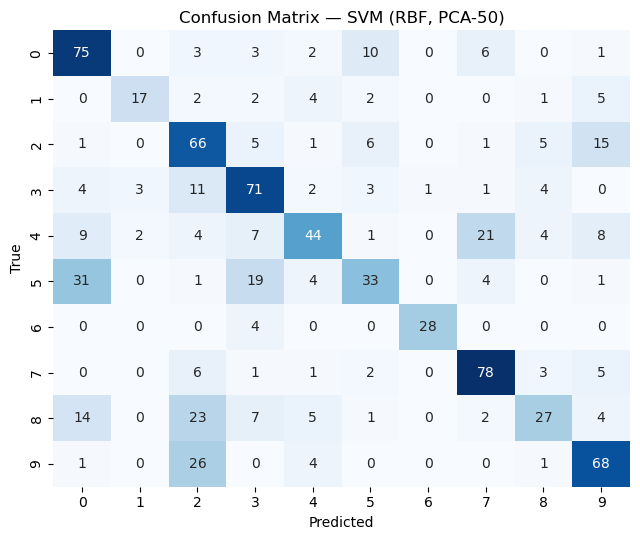

In [15]:
plot_confusion_mat(y_test, y_pred_svm, "SVM (RBF, PCA-50)", BASE_DIR / "03b_svm_cf.png")


## Observations

- **Both** Logistic Regression and SVM had **similar overall performance** (almost identical F1-Scores and Accuracy Scores)
    - Nonlinear RBF kernel in SVM did not provide a significant performance gain
- **Both** models **confuse class 2, 8, 9** (children_playing, siren, street_music) → **PCA-50 feature extraction** failed to preserve sufficient spectral and temporal information
- Similarity in performance suggest the **bottleneck** is in **feature representation**

**Next Steps:**
- Explore tree-based models using the 1200 MFCC features


## History Gradient Boost

1. **Extract** the features (`X`) and label (`y`)
    - Scaling not required for tree-based models
2. Create **Grid Search** params and **Execute** the Grid Search for `HistGradientBoost`
3. **Evaluate** by making predictions on `X_test`


In [16]:
# Extract X and y
# ---------------

X_train = train_mfcc_df.drop(columns=["sample", "label"]).values
y_train = train_mfcc_df["label"].values

X_test  = test_mfcc_df.drop(columns=["sample", "label"]).values
y_test  = test_mfcc_df["label"].values

print("Shapes - MFCC (X_train, y_train, X_test, y_test):",
      X_train.shape, y_train.shape, X_test.shape, y_test.shape)

Shapes - MFCC (X_train, y_train, X_test, y_test): (1721, 1200) (1721,) (837, 1200) (837,)


In [44]:
# Grid Parameters
# ---------------

hgb = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    max_bins=128,          # ↓ cheaper histograms
    max_depth=3            # small trees generalize well
)

param_grid = {
    "learning_rate":    [0.05, 0.08, 0.1],
    "min_samples_leaf": [20, 50, 100],
    "max_iter":         [200, 400],       # early stopping will stop earlier anyway
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = HalvingGridSearchCV(
    estimator=hgb,
    param_grid=param_grid,
    factor=3, # aggressive elimination
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    verbose=2,
    refit=True
)


## Grid Search

**Note:** Takes ~10 mins to run


In [45]:
# Execute Grid Search
# -------------------

grid.fit(X_train, y_train, sample_weight=sample_weight)

print("Best HGB params:", grid.best_params_)
print("Best CV macro-F1:", f"{grid.best_score_:.4f}")

best_hgb = grid.best_estimator_


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 191
max_resources_: 1721
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 18
n_resources: 191
Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END learning_rate=0.05, max_iter=200, min_samples_leaf=20; total time=   2.9s
[CV] END learning_rate=0.05, max_iter=200, min_samples_leaf=20; total time=   2.4s
[CV] END learning_rate=0.05, max_iter=200, min_samples_leaf=20; total time=   3.6s
[CV] END learning_rate=0.05, max_iter=200, min_samples_leaf=20; total time=   4.3s
[CV] END learning_rate=0.05, max_iter=200, min_samples_leaf=20; total time=   2.8s
[CV] END learning_rate=0.05, max_iter=200, min_samples_leaf=50; total time=   2.5s
[CV] END learning_rate=0.05, max_iter=200, min_samples_leaf=50; total time=   1.7s
[CV] END learning_rate=0.05, max_iter=200, min_samples_leaf=50; total time=   1.8s
[CV] END learning_rate=0.05, max_iter=200, min_samples_leaf=50; total time=

In [46]:
# Evaluate
# --------

y_pred_hgb = best_hgb.predict(X_test)
print_classification_report(y_test, y_pred_hgb, "HistGradientBoost (MFCC-1200)")
print_macro_metrics(y_test, y_pred_hgb, "HistGradientBoost (MFCC-1200)")



=== Classification Report: HistGradientBoost (MFCC-1200) ===
              precision    recall  f1-score   support

           0     0.8351    0.8100    0.8223       100
           1     0.6364    0.4242    0.5091        33
           2     0.4756    0.7800    0.5909       100
           3     0.8140    0.7000    0.7527       100
           4     0.6180    0.5500    0.5820       100
           5     0.8649    0.6882    0.7665        93
           6     0.9355    0.9062    0.9206        32
           7     0.7849    0.7604    0.7725        96
           8     0.8571    0.4337    0.5760        83
           9     0.5252    0.7300    0.6109       100

    accuracy                         0.6846       837
   macro avg     0.7347    0.6783    0.6904       837
weighted avg     0.7224    0.6846    0.6874       837

 === HistGradientBoost (MFCC-1200) ===
  Acc    | Prec   | Rec    | F1-Score
  0.6846 | 0.7347 | 0.6783 | 0.6904


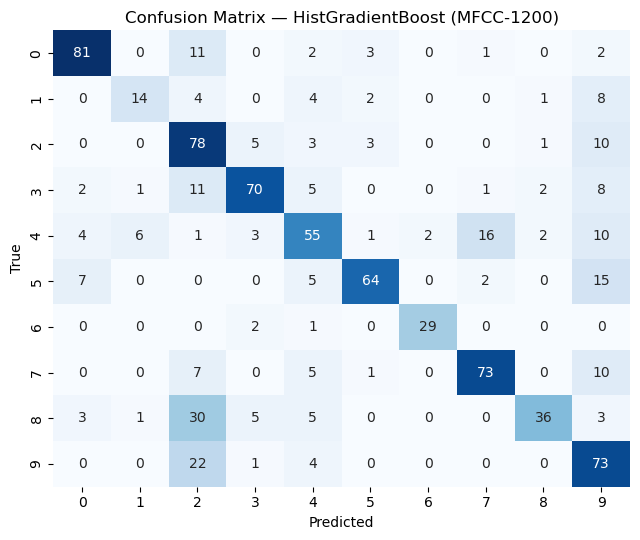

In [47]:
plot_confusion_mat(y_test, y_pred_hgb, "HistGradientBoost (MFCC-1200)", BASE_DIR / "03c_hgb_cf.png")


## XGBoost

1. (Already Done) **Extract** the features (`X`) and label (`y`)
    - Scaling not required for tree-based models
2. Create a small validation split (`0.12`) for early stop
3. **Train** XGBoost on `X_tr`
4. **Evaluate** by making predictions on `X_test`


In [48]:
# Train-Val Split
# ---------------

X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
    X_train, y_train, sample_weight,
    test_size=0.12, stratify=y_train, random_state=RANDOM_STATE
)


In [59]:
# Define XGBoost 
# --------------

# histogram algorithm; CPU; modest depth)
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(classes),
    n_estimators=600,
    learning_rate=0.07,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
    eval_metric="mlogloss"
)


In [61]:
# Train XGB
# ---------

xgb.fit(
    X_tr, y_tr,
    sample_weight=sw_tr,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[sw_val],
    verbose=50
)


[0]	validation_0-mlogloss:2.13180
[50]	validation_0-mlogloss:0.54215
[100]	validation_0-mlogloss:0.34826
[150]	validation_0-mlogloss:0.28850
[200]	validation_0-mlogloss:0.26076
[250]	validation_0-mlogloss:0.24489
[300]	validation_0-mlogloss:0.23535
[350]	validation_0-mlogloss:0.22900
[400]	validation_0-mlogloss:0.22496
[450]	validation_0-mlogloss:0.22242
[500]	validation_0-mlogloss:0.22004
[550]	validation_0-mlogloss:0.21930
[599]	validation_0-mlogloss:0.21826


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.07, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=1, num_class=10, num_parallel_tree=None, ...)

In [64]:
# Evaluate
# --------

y_pred_xgb = xgb.predict(X_test)
print_classification_report(y_test, y_pred_xgb, "XGB (MFCC-1200)")
print_macro_metrics(y_test, y_pred_xgb, "XGB (MFCC-1200)")



=== Classification Report: XGB (MFCC-1200) ===
              precision    recall  f1-score   support

           0     0.7864    0.8100    0.7980       100
           1     0.7083    0.5152    0.5965        33
           2     0.4481    0.6900    0.5433       100
           3     0.8090    0.7200    0.7619       100
           4     0.6277    0.5900    0.6082       100
           5     0.8710    0.8710    0.8710        93
           6     1.0000    0.9062    0.9508        32
           7     0.8506    0.7708    0.8087        96
           8     0.7333    0.3976    0.5156        83
           9     0.6050    0.7200    0.6575       100

    accuracy                         0.7013       837
   macro avg     0.7439    0.6991    0.7112       837
weighted avg     0.7246    0.7013    0.7030       837

 === XGB (MFCC-1200) ===
  Acc    | Prec   | Rec    | F1-Score
  0.7013 | 0.7439 | 0.6991 | 0.7112


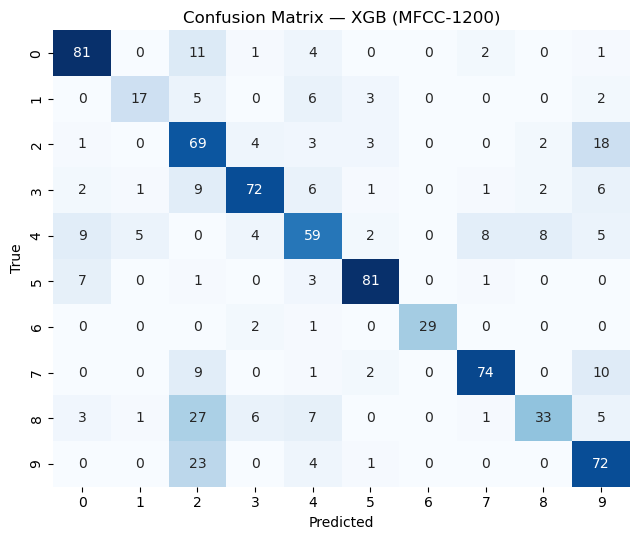

In [65]:
plot_confusion_mat(y_test, y_pred_xgb, "XGB (MFCC-1200)", BASE_DIR / "03d_xgb_cf.png")


### Observations

- **Both** HGB and XGB **performed better** than the **PCA-50 based models** (~10% higher F1-Score and Accuracy)
- Confusion between classes 2, 8, 9 (children_playing, siren, street_music) still exist
    - Overlap in temporal-spectral cues even in MFCC space
- **XGB** performed **better** than **HGB** (~2% higher F1-Score and Accuracy)
- **XGB** was able to differentiat the different classes better than **HGB**
- **XGB** has more **sophisticated boosting mechanism** and **fine-tuned regularization** → Performed better than HGB


## Conclusion

- **Classical models** using **PCA-50 features** (Logistic Regression, SVM) achieved macro-F1 ≈ 0.61 indicating **limited discriminative power** due to **dimensionality reduction loss**
- **Tree-based models** (HistGradientBoost and XGBoost) resulted in a **significant performance uplift** to macro-F1 ≈ 0.69–0.71
- This improvement highlights the **importance of richer acoustic representation** for environmental sound classification
- **XGBoost** (macro-F1 = 0.7112) marginally outperformed **HistGradientBoost** (macro-F1 = 0.6904) benefiting from finer regularization controls and adaptive learning rate scheduling
- Persistent confusion between classes 2, 8, and 9 (children_playing, siren, street_music) indicates **spectral overlap** and **insufficient temporal separation** even in MFCC features



## Future Enhancements 

**1. Temporal Segment Pooling**

- Instead of global statistical summaries (mean, median, quartiles, etc.), each MFCC coefficient can be divided into 20 equal time segments, extracting the mean per segment
- This creates 2,400 static features (120 coefficients × 20 segments) that capture the temporal evolution of each sound event
- Such segmented pooling retains temporal shape and transition information that global statistics lose, improving the model’s ability to distinguish transient sounds (e.g., siren, dog bark)

**2. Mean + Standard Deviation per Segment**

- A more robust variant computes both mean and standard deviation within each segment, balancing temporal resolution and noise sensitivity
- This doubles the feature count but can better represent energy variation across time windows.

**3. Deep Sequence Models**

- The 2,400-feature representation can be reshaped into a (20, 120) time–feature matrix, enabling use of temporal deep learning models such as:
    - 1D CNNs: for local temporal feature extraction
    - Temporal Convolutional Networks (TCN): for long-range dependencies using dilated convolutions
    - 1D CNN + GRU/LSTM hybrids: combining local pattern detection with sequential memory
- These architectures can learn nonlinear temporal dependencies without requiring spectrogram images

**4. Comparative Evaluation**

- Conduct an ablation study comparing:
    - Global statistics (current 1,200 features) vs. Segment-based pooling (2,400 features)
    - Classical ML (HGB/XGB) vs. Deep temporal models (1D CNN/TCN/GRU)
- Evaluation using macro-F1 will reveal whether temporal segmentation yields consistent performance gains across all sound categories.
